In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('online_gaming_behavior_dataset.csv')

# Part 1: Data Understanding

In [2]:
# Display Basic Info
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (40034, 13)

Column names:
['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel']


In [3]:
# Show Each Column Info (Data Type)
print("\nColumn Info:")
print(df.info())


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(

In [4]:
# Show 10 Row (Overview of Dataset)
df.head(10)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.561855,0,Easy,2,81,74,22,Low
6,9006,25,Male,USA,Action,9.752716,0,Hard,1,50,13,2,Low
7,9007,25,Female,Asia,RPG,4.401729,0,Medium,10,48,27,23,Medium
8,9008,38,Female,Europe,Simulation,18.152733,0,Easy,5,101,23,41,Medium
9,9009,38,Female,Other,Sports,23.942772,0,Easy,13,95,99,36,High


### Type of Variable Summary

In [5]:
# Separate Numerical and Categorical Variable
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: Index(['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases',
       'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel',
       'AchievementsUnlocked'],
      dtype='object')

Categorical columns: Index(['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel'], dtype='object')


In [6]:
print("=" * 60)
print("           FULL DATASET STATISTICAL PROFILE")
print("=" * 60)

# Numeric columns
print("\nNUMERIC COLUMNS:")
df.describe().T.assign(
    range=lambda x: x['max'] - x['min'],
    cv=lambda x: (x['std'] / x['mean'] * 100).round(1)
)[['count','mean','std','min','25%','50%','75%','max','range','cv']]

           FULL DATASET STATISTICAL PROFILE

NUMERIC COLUMNS:


,count,mean,std,min,25%,50%,75%,max,range,cv
PlayerID,40034.0,29016.500000,11556.964675,9000.000000,19008.250000,29016.500000,39024.750000,49033.000000,40033.000000,39.8
Age,40034.0,31.992531,10.043227,15.000000,23.000000,32.000000,41.000000,49.000000,34.000000,31.4
PlayTimeHours,40034.0,12.024365,6.914638,0.000115,6.067501,12.008002,17.963831,23.999592,23.999477,57.5
InGamePurchases,40034.0,0.200854,0.400644,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,199.5
SessionsPerWeek,40034.0,9.471774,5.763667,0.000000,4.000000,9.000000,14.000000,19.000000,19.000000,60.9
AvgSessionDurationMinutes,40034.0,94.792252,49.011375,10.000000,52.000000,95.000000,137.000000,179.000000,169.000000,51.7
PlayerLevel,40034.0,49.655568,28.588379,1.000000,25.000000,49.000000,74.000000,99.000000,98.000000,57.6
AchievementsUnlocked,40034.0,24.526477,14.430726,0.000000,12.000000,25.000000,37.000000,49.000000,49.000000,58.8


In [7]:
# Summary for Categorical VAriable
cat_features = [c for c in categorical_cols if c != 'Heart Disease Status']
print("\n=== Categorical Summary ===")
for col in cat_features:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


=== Categorical Summary ===

Gender value counts:
Gender
Male      23959
Female    16075
Name: count, dtype: int64

Location value counts:
Location
USA       16000
Europe    12004
Asia       8095
Other      3935
Name: count, dtype: int64

GameGenre value counts:
GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952
Name: count, dtype: int64

GameDifficulty value counts:
GameDifficulty
Easy      20015
Medium    12011
Hard       8008
Name: count, dtype: int64

EngagementLevel value counts:
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


### Exploratory Data Analysis

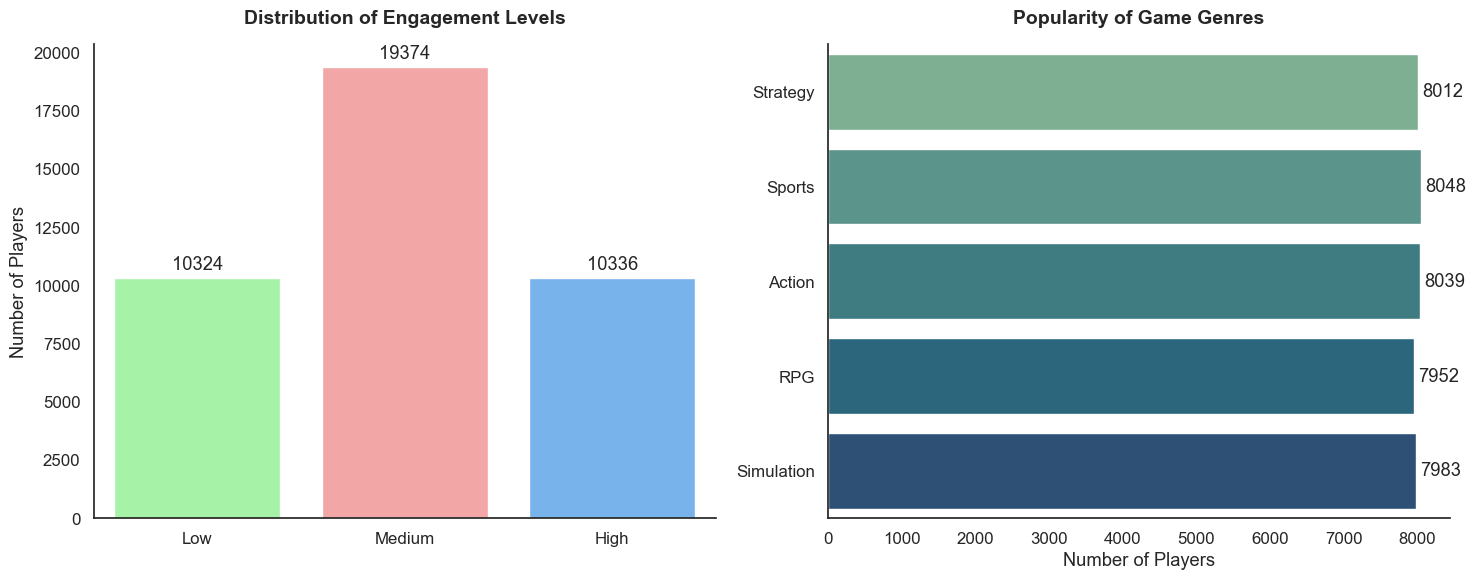

In [8]:
# Set a premium, clean visual style
sns.set_theme(style="white", context="notebook", font_scale=1.1)

# Remove top and right borders globally for a modern look
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Comparison between engagement level
# Engagement Level with custom pastel colors and data labels
sns.countplot(
    data=df, x='EngagementLevel', hue='EngagementLevel',
    order=['Low', 'Medium', 'High'], ax=axes[0], 
    palette=['#ff9999','#66b3ff','#99ff99'], legend=False
)
axes[0].set_title('Distribution of Engagement Levels', fontsize=14, weight='bold', pad=15)
axes[0].set_ylabel('Number of Players')
axes[0].set_xlabel('')

# Add value labels to the bars
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Comparison popularity of game genre
sns.countplot(
    data=df, y='GameGenre', hue='GameGenre',
    ax=axes[1], palette='crest', legend=False
)
axes[1].set_title('Popularity of Game Genres', fontsize=14, weight='bold', pad=15)
axes[1].set_xlabel('Number of Players')
axes[1].set_ylabel('')

# Add value labels to the horizontal bars
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

sns.despine() 
plt.tight_layout()
plt.show()

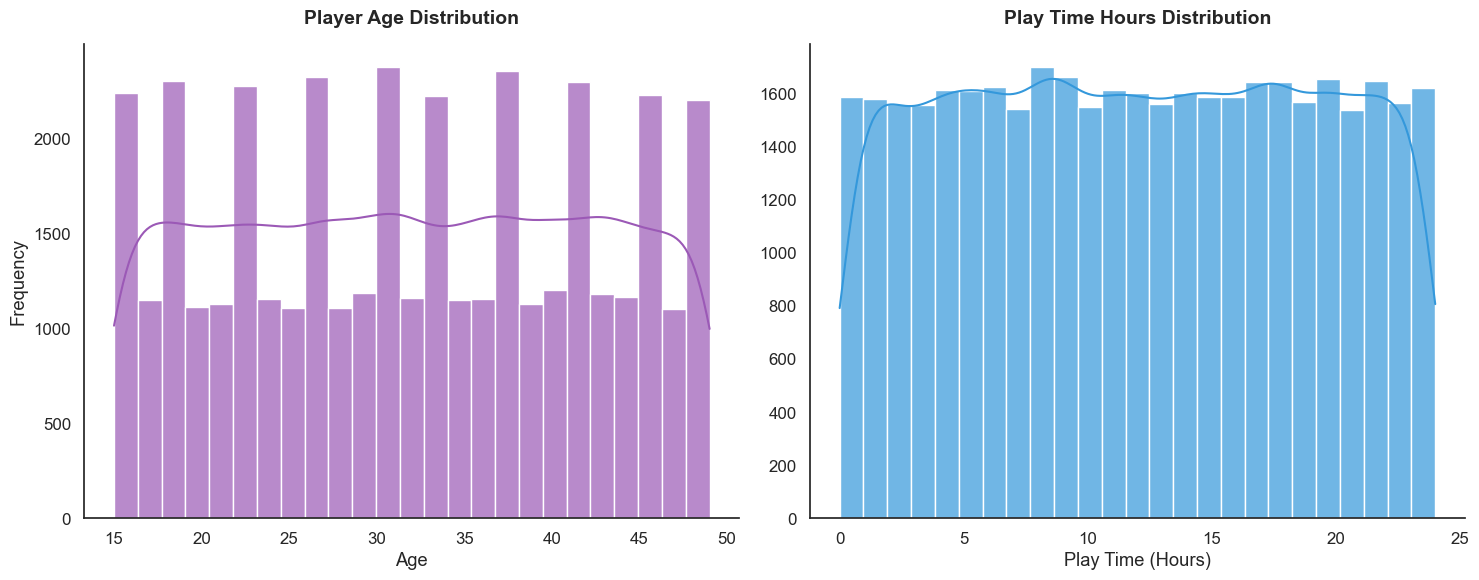

In [9]:
# Histrogram for show distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Age Distribution
sns.histplot(
    df['Age'], bins=25, kde=True, ax=axes[0], 
    color='#9b59b6', edgecolor='white', alpha=0.7
)
axes[0].set_title('Player Age Distribution', fontsize=14, weight='bold', pad=15)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Play Time Hours Distribution
sns.histplot(
    df['PlayTimeHours'], bins=25, kde=True, ax=axes[1], 
    color='#3498db', edgecolor='white', alpha=0.7
)
axes[1].set_title('Play Time Hours Distribution', fontsize=14, weight='bold', pad=15)
axes[1].set_xlabel('Play Time (Hours)')
axes[1].set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

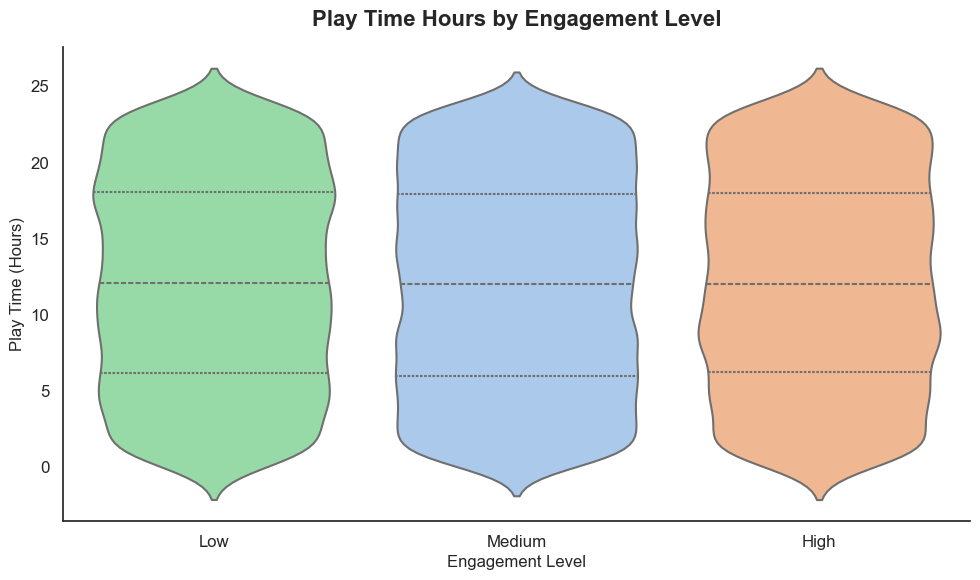

In [10]:
# Violin Plot
plt.figure(figsize=(10, 6))

# Using a Violin Plot for a more advanced statistical look
sns.violinplot(
    data=df, x='EngagementLevel', y='PlayTimeHours', 
    hue='EngagementLevel', order=['Low', 'Medium', 'High'], 
    palette='pastel', inner='quartile', legend=False,
    linewidth=1.5
)
               
plt.title('Play Time Hours by Engagement Level', fontsize=16, weight='bold', pad=15)
plt.xlabel('Engagement Level', fontsize=12)
plt.ylabel('Play Time (Hours)', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

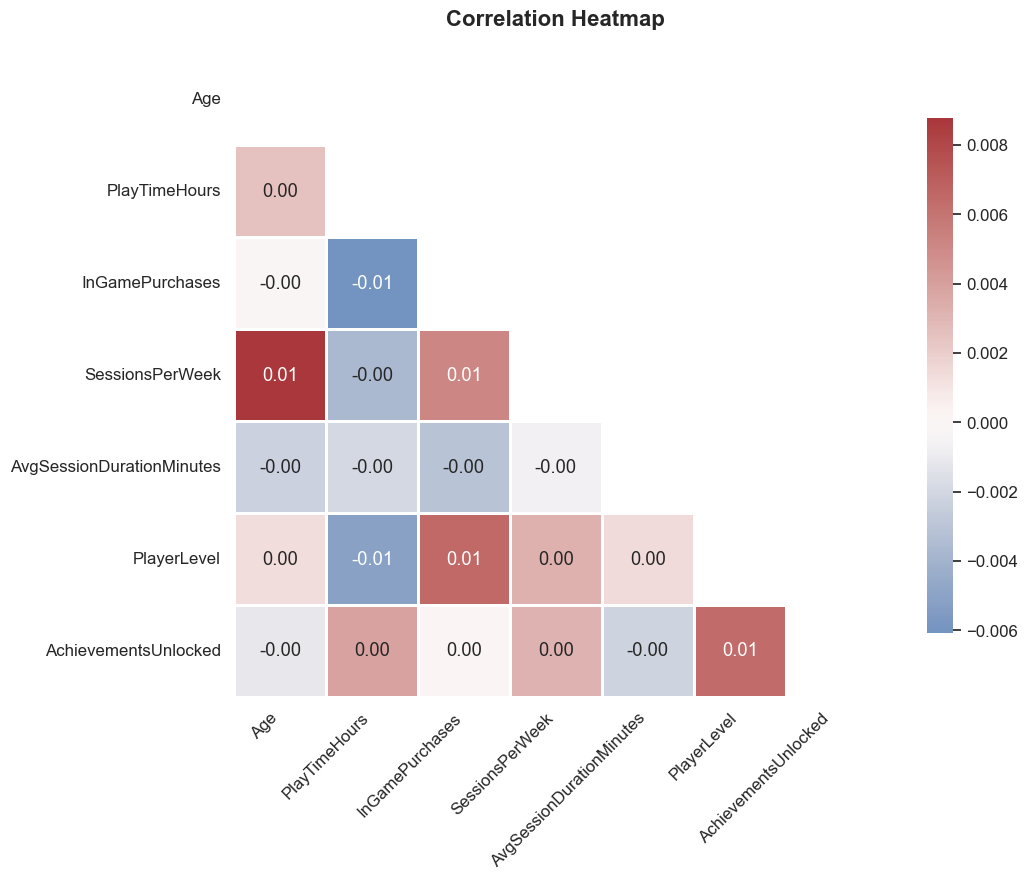

In [11]:
# Half-Masked Correlation Heatmap for find correlation of target variable among each numerical column
plt.figure(figsize=(12, 9))

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
if 'PlayerID' in numerical_cols:
    numerical_cols = numerical_cols.drop('PlayerID')

corr_matrix = df[numerical_cols].corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot a custom, masked heatmap
sns.heatmap(
    corr_matrix, mask=mask, annot=True, cmap='vlag', 
    fmt=".2f", linewidths=1, cbar_kws={"shrink": .8}, 
    square=True, center=0
)
            
plt.title('Correlation Heatmap', fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotate labels so they fit nicely
plt.tight_layout()
plt.show()

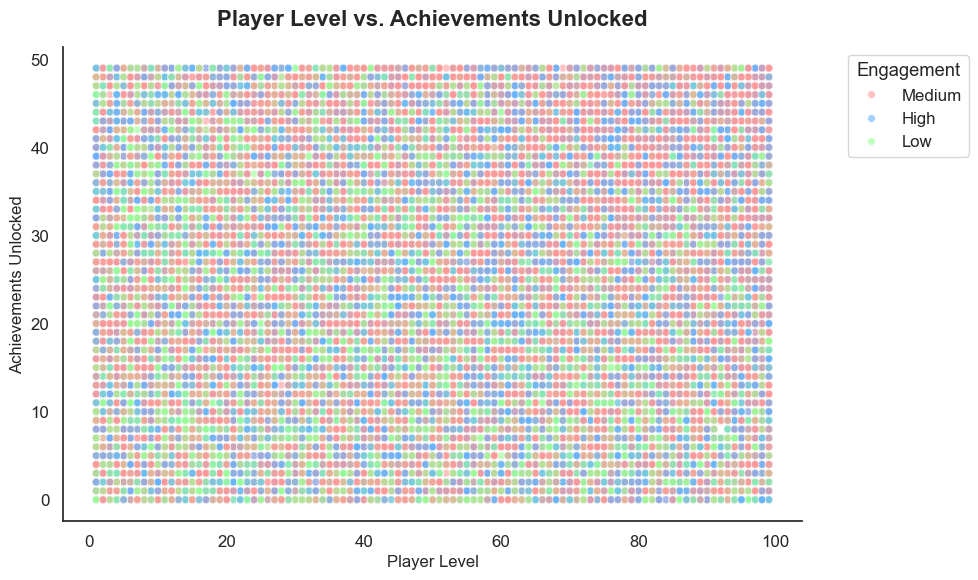

In [12]:
# Scatter plot for Level vs Achievements
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='PlayerLevel', 
    y='AchievementsUnlocked', 
    hue='EngagementLevel', 
    palette=['#ff9999','#66b3ff','#99ff99'],
    alpha=0.6, # Adds transparency to see overlapping points
    s=30       # Size of the dots
)

plt.title('Player Level vs. Achievements Unlocked', fontsize=16, weight='bold', pad=15)
plt.xlabel('Player Level', fontsize=12)
plt.ylabel('Achievements Unlocked', fontsize=12)

# Move the legend outside the plot
plt.legend(title='Engagement', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

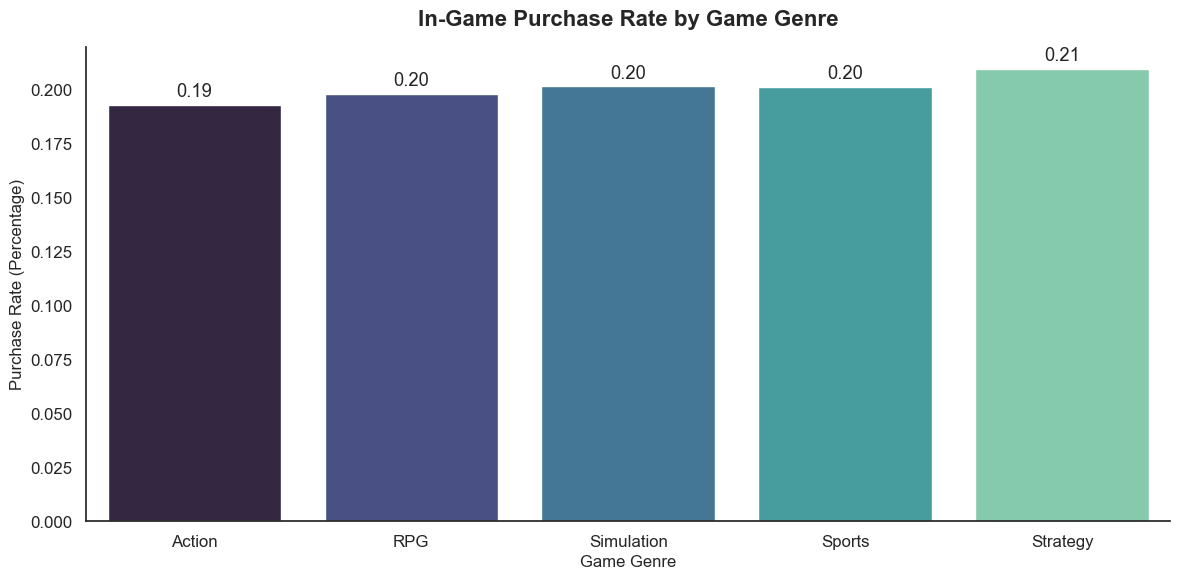

In [13]:
# Bar Chart
# Comparison of game genre with in-game purchase rate
plt.figure(figsize=(12, 6))

# Calculate the purchase rate (mean of 0s and 1s) per genre
purchase_rates = df.groupby('GameGenre')['InGamePurchases'].mean().reset_index()

# Plot the conversion rate
sns.barplot(
    data=purchase_rates, 
    x='GameGenre', 
    y='InGamePurchases', 
    palette='mako',
    hue='GameGenre',
    legend=False
)

plt.title('In-Game Purchase Rate by Game Genre', fontsize=16, weight='bold', pad=15)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Purchase Rate (Percentage)', fontsize=12)

# Add percentage labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

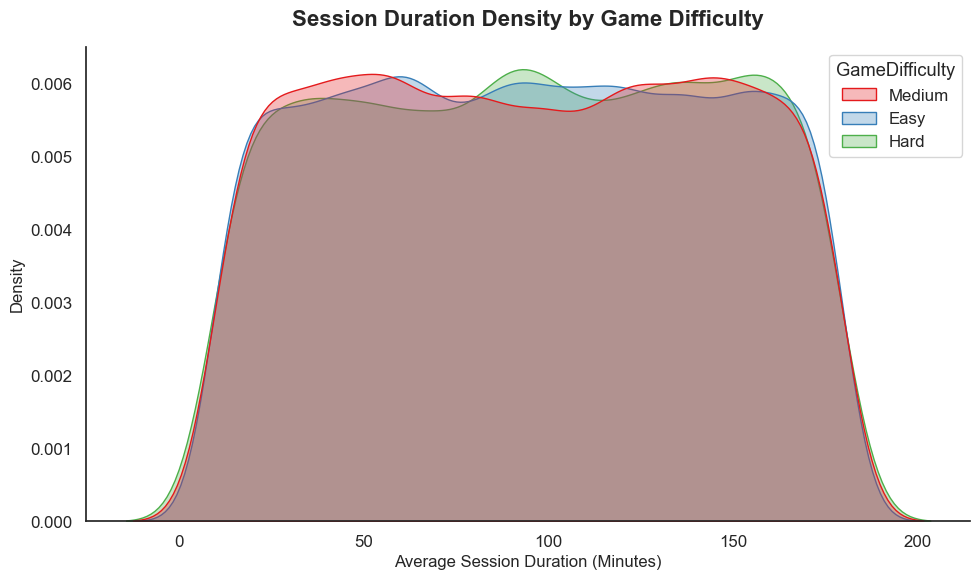

In [14]:
# Density plot for session duration based on difficulty
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df, 
    x='AvgSessionDurationMinutes', 
    hue='GameDifficulty', 
    fill=True, 
    common_norm=False, 
    palette='Set1',
    alpha=0.3
)

plt.title('Session Duration Density by Game Difficulty', fontsize=16, weight='bold', pad=15)
plt.xlabel('Average Session Duration (Minutes)', fontsize=12)
plt.ylabel('Density', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

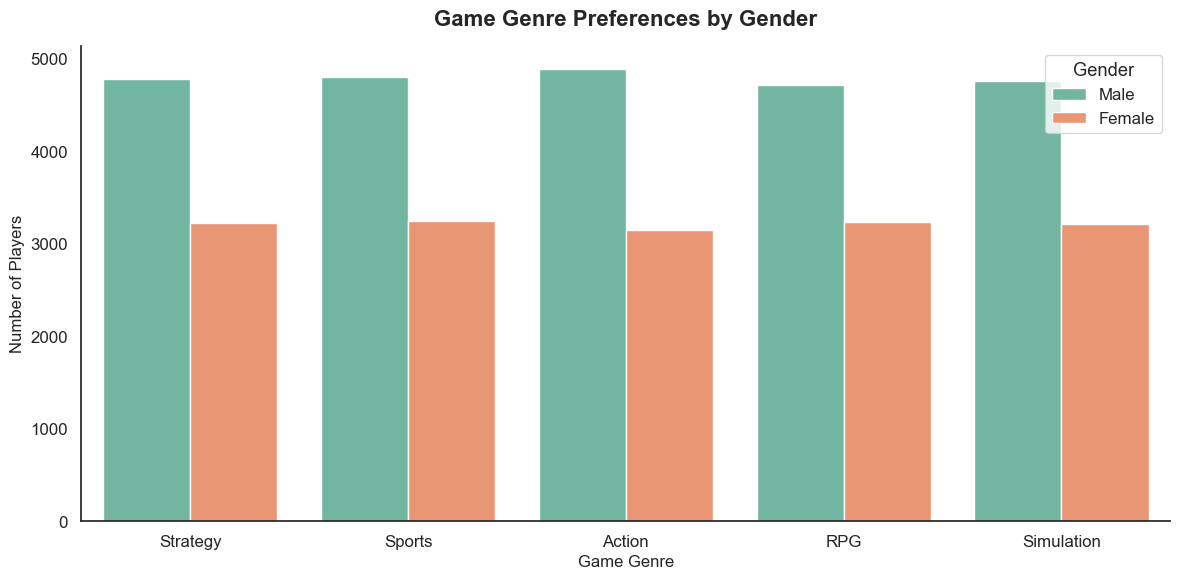

In [15]:
# Group-Bar Chart
# Comparison game genre and gender with number of players 
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df, 
    x='GameGenre', 
    hue='Gender', 
    palette='Set2'
)

plt.title('Game Genre Preferences by Gender', fontsize=16, weight='bold', pad=15)
plt.xlabel('Game Genre', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

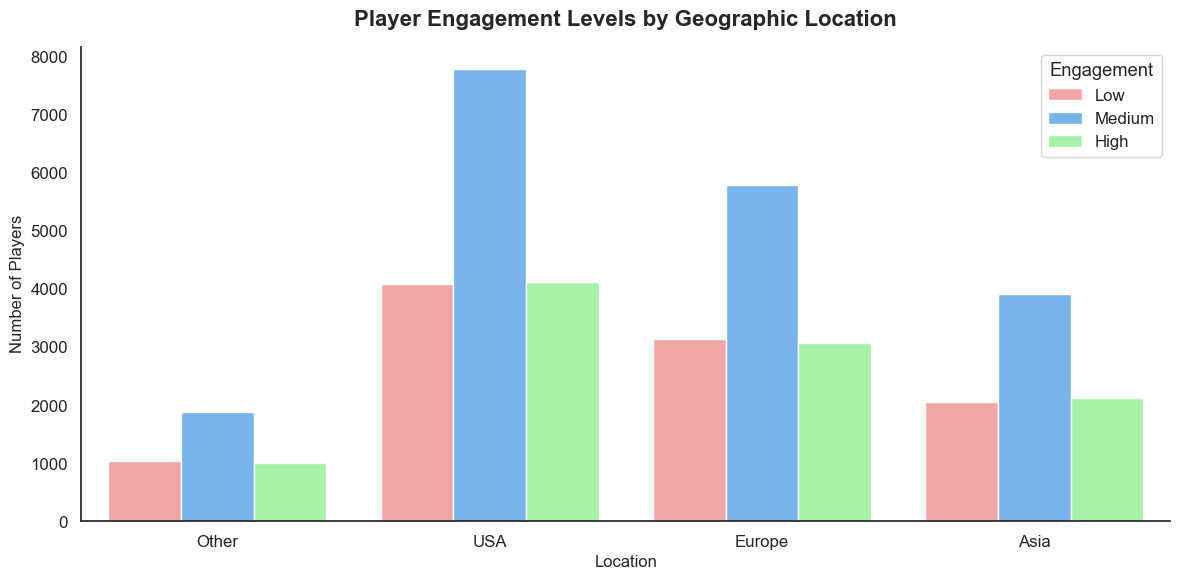

In [16]:
# Group-Bar Chart
# Comparison of players engagement level and geographical location with number of players
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df, 
    x='Location', 
    hue='EngagementLevel',
    hue_order=['Low', 'Medium', 'High'],
    palette=['#ff9999','#66b3ff','#99ff99']
)

plt.title('Player Engagement Levels by Geographic Location', fontsize=16, weight='bold', pad=15)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.legend(title='Engagement', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

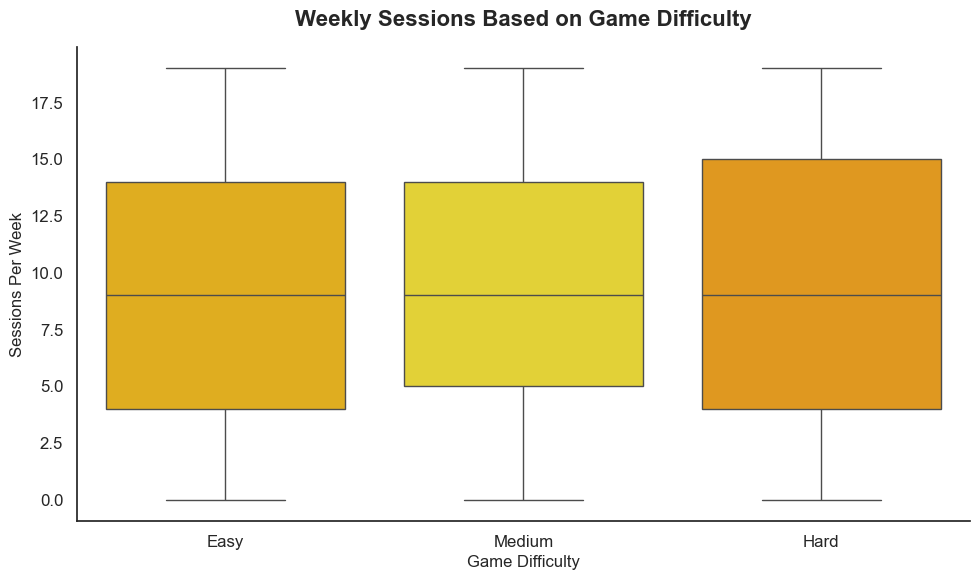

In [17]:
# Boxplot
# Better visualization to show the best five statistic value with weekly sessions based on game difficulty
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='GameDifficulty', 
    y='SessionsPerWeek', 
    hue='GameDifficulty',
    order=['Easy', 'Medium', 'Hard'],
    palette='Wistia',
    legend=False
)

plt.title('Weekly Sessions Based on Game Difficulty', fontsize=16, weight='bold', pad=15)
plt.xlabel('Game Difficulty', fontsize=12)
plt.ylabel('Sessions Per Week', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

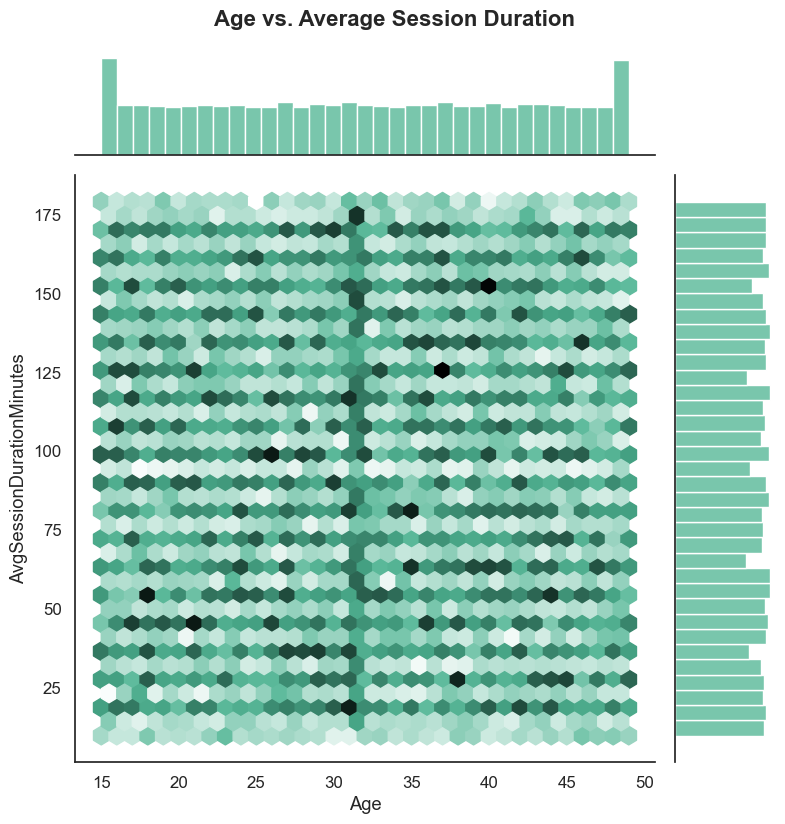

In [18]:
# Using a JointGrid/JointPlot for a combined visualization
g = sns.jointplot(
    data=df, 
    x='Age', 
    y='AvgSessionDurationMinutes', 
    kind='hex', # Hexbin plot handles large datasets beautifully
    color='#4CB391',
    height=8
)

g.fig.suptitle('Age vs. Average Session Duration', fontsize=16, weight='bold', y=1.03)

plt.show()

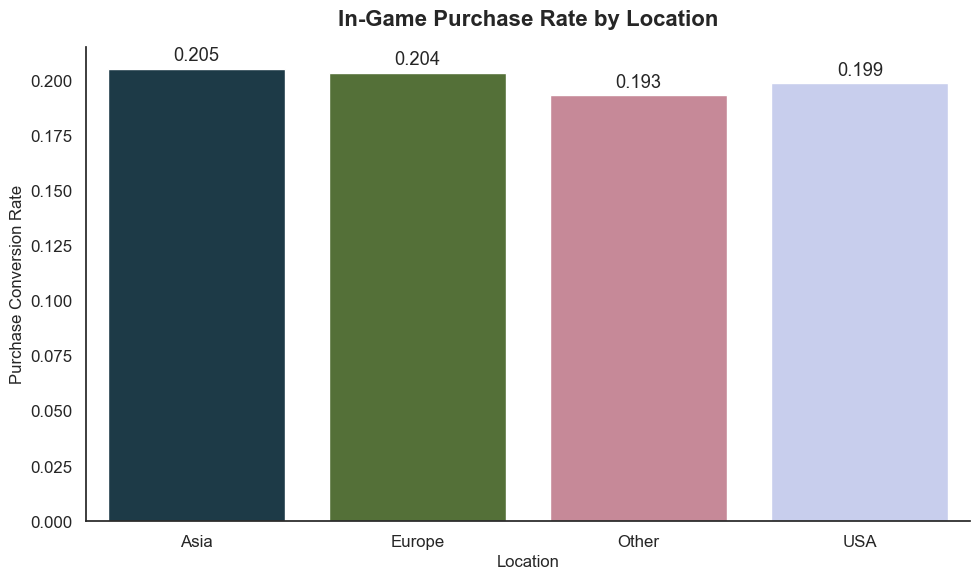

In [19]:
# Bar Chart 
# Comparison of in-game purchase rate with location
plt.figure(figsize=(10, 6))

location_purchases = df.groupby('Location')['InGamePurchases'].mean().reset_index()

sns.barplot(
    data=location_purchases, 
    x='Location', 
    y='InGamePurchases', 
    hue='Location',
    palette='cubehelix',
    legend=False
)

plt.title('In-Game Purchase Rate by Location', fontsize=16, weight='bold', pad=15)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Purchase Conversion Rate', fontsize=12)

# Add data labels
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()

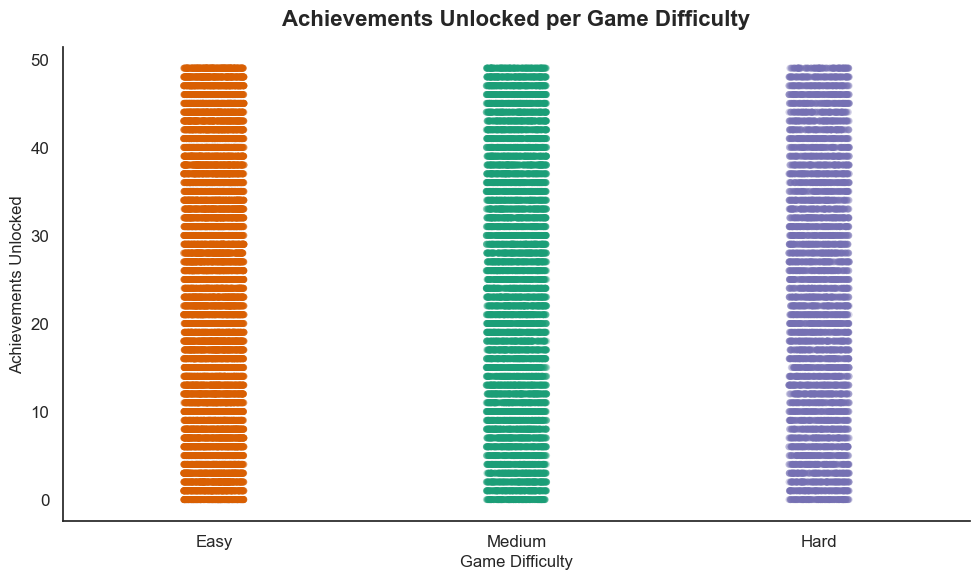

In [20]:
# Strip plot 
# Comparison achievements unlocked per game difficulty
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df, 
    x='GameDifficulty', 
    y='AchievementsUnlocked', 
    hue='GameDifficulty',
    order=['Easy', 'Medium', 'Hard'],
    palette='Dark2',
    alpha=0.3, # Transparency to handle overlapping dots
    jitter=True, # Spreads the dots out so they don't form a single line
    legend=False
)

plt.title('Achievements Unlocked per Game Difficulty', fontsize=16, weight='bold', pad=15)
plt.xlabel('Game Difficulty', fontsize=12)
plt.ylabel('Achievements Unlocked', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

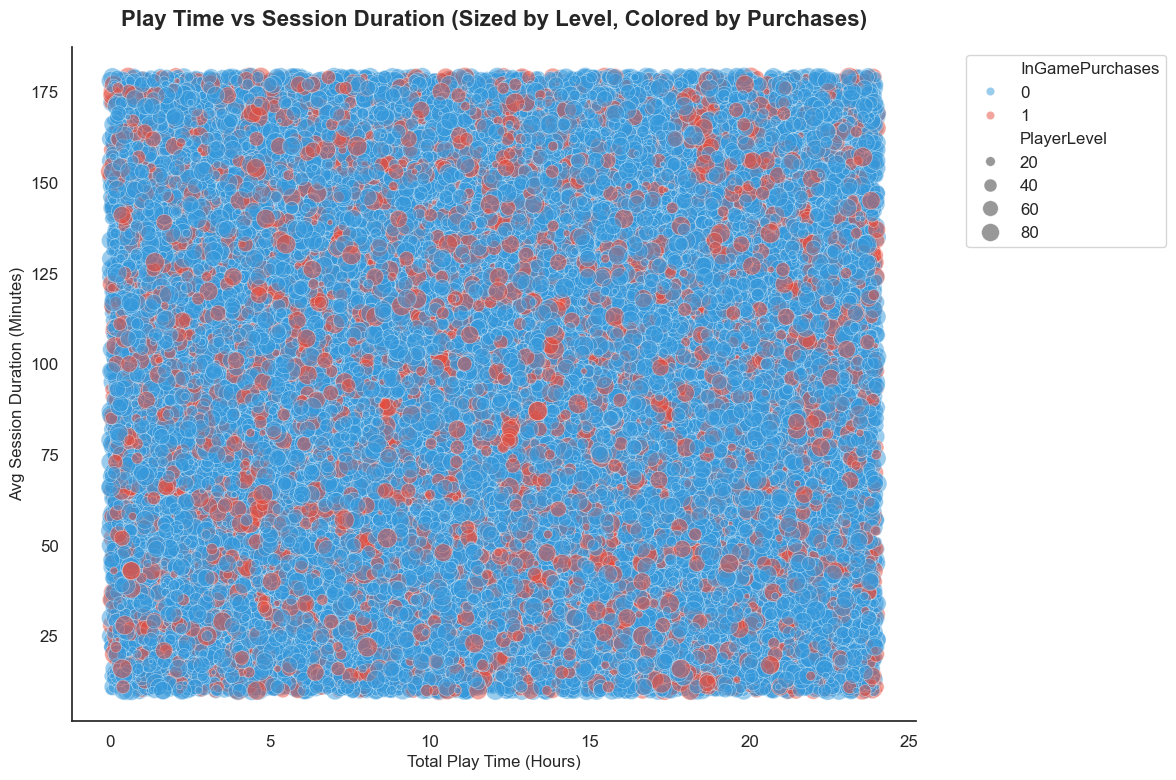

In [21]:
# Scatter Plot
# Play Time vs Session Duration
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df, 
    x='PlayTimeHours', 
    y='AvgSessionDurationMinutes', 
    hue='InGamePurchases', 
    size='PlayerLevel',
    sizes=(10, 200), # Min and max dot sizes
    palette=['#3498db', '#e74c3c'], # Blue for no purchase, Red for purchase
    alpha=0.5
)

plt.title('Play Time vs Session Duration (Sized by Level, Colored by Purchases)', fontsize=16, weight='bold', pad=15)
plt.xlabel('Total Play Time (Hours)', fontsize=12)
plt.ylabel('Avg Session Duration (Minutes)', fontsize=12)

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

### Feature Engineering

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Feature Engineering 
# Calculate Total Minutes Played in a Typical Week
df['TotalWeeklyMinutes'] = df['SessionsPerWeek'] * df['AvgSessionDurationMinutes']

# Calculate Achievements per level 
df['AchievementRate'] = df['AchievementsUnlocked'] / df['PlayerLevel']

# Group Ages into Categorical Bins
age_bins = [0, 19, 35, 100]
age_labels = ['Teen', 'YoungAdult', 'Adult']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Verify the Dataset
print("\nFirst 3 rows of processed data:")
display(df.head(3))


First 3 rows of processed data:


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalWeeklyMinutes,AchievementRate,AgeGroup
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,648,0.316456,Adult
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,720,0.909091,YoungAdult
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,2272,1.171429,YoungAdult


### Detect Missing Value

In [23]:
# Checking for Missing Values in Each Column
missing_values = df.isnull().sum()

# Display the Results
print("Missing values per column:")
print(missing_values)

Missing values per column:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
TotalWeeklyMinutes           0
AchievementRate              0
AgeGroup                     0
dtype: int64


### Drop Useless Column

In [24]:
# Drop Useless Column
df = df.drop('PlayerID', axis=1, errors='ignore')

# Verify The Final Dataset
print("Final Dataset Shape:", df.shape)
print("\nFirst 3 rows of processed data:")
display(df.head(3))

Final Dataset Shape: (40034, 15)

First 3 rows of processed data:


,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalWeeklyMinutes,AchievementRate,AgeGroup
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,648,0.316456,Adult
1,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,720,0.909091,YoungAdult
2,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,2272,1.171429,YoungAdult


### Detect Outliers 

In [25]:
# Detect Outliers
# Define the Numerical Columns to Check
num_cols = [
    'Age', 'PlayTimeHours', 'SessionsPerWeek', 
    'AvgSessionDurationMinutes', 'PlayerLevel', 
    'AchievementsUnlocked', 'TotalWeeklyMinutes', 'AchievementRate'
]

# Loop Through Each Column to Find Outliers using the IQR Method
print("Outlier counts per column, split by EngagementLevel:")
for col in num_cols:
    print(f"\n{col}:")
    for level in df['EngagementLevel'].unique():
        sub = df.loc[df['EngagementLevel'] == level, col]
        Q1 = sub.quantile(0.25)
        Q3 = sub.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = sub[(sub < lower_bound) | (sub > upper_bound)]
        print(f"  {level}: {len(outliers)} outliers")

Outlier counts per column, split by EngagementLevel:

Age:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

PlayTimeHours:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

SessionsPerWeek:
  Medium: 0 outliers
  High: 340 outliers
  Low: 376 outliers

AvgSessionDurationMinutes:
  Medium: 0 outliers
  High: 225 outliers
  Low: 0 outliers

PlayerLevel:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

AchievementsUnlocked:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

TotalWeeklyMinutes:
  Medium: 192 outliers
  High: 428 outliers
  Low: 781 outliers

AchievementRate:
  Medium: 2143 outliers
  High: 1219 outliers
  Low: 1227 outliers


In [26]:
def cap_outliers_iqr(dataframe, target_col, grouping_col):
    """Caps outliers to the IQR upper and lower bounds per group."""
    df_capped = dataframe.copy()
    
    for level in df_capped[grouping_col].unique():
        # Isolate the group
        sub = df_capped.loc[df_capped[grouping_col] == level, target_col]
        
        # Calculate bounds
        Q1 = sub.quantile(0.25)
        Q3 = sub.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Apply the cap to extreme values
        df_capped.loc[(df_capped[grouping_col] == level) & (df_capped[target_col] < lower_bound), target_col] = lower_bound
        df_capped.loc[(df_capped[grouping_col] == level) & (df_capped[target_col] > upper_bound), target_col] = upper_bound
        
    return df_capped

# Apply the capping function to the two columns with outliers
df = cap_outliers_iqr(df, 'SessionsPerWeek', 'EngagementLevel')
df = cap_outliers_iqr(df, 'AvgSessionDurationMinutes', 'EngagementLevel')
df = cap_outliers_iqr(df, 'TotalWeeklyMinutes', 'EngagementLevel')
df = cap_outliers_iqr(df, 'AchievementRate', 'EngagementLevel')

# Loop Through Each Column to Find Outliers using the IQR Method
print("Outlier counts per column, split by EngagementLevel:")
for col in num_cols:
    print(f"\n{col}:")
    for level in df['EngagementLevel'].unique():
        sub = df.loc[df['EngagementLevel'] == level, col]
        Q1 = sub.quantile(0.25)
        Q3 = sub.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = sub[(sub < lower_bound) | (sub > upper_bound)]
        print(f"  {level}: {len(outliers)} outliers")

print("Outliers have been successfully capped!")

C:\Users\SCSM11\AppData\Local\Temp\ipykernel_20112\3139830834.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-4.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[(df_capped[grouping_col] == level) & (df_capped[target_col] < lower_bound), target_col] = lower_bound
C:\Users\SCSM11\AppData\Local\Temp\ipykernel_20112\3139830834.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '383.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_capped.loc[(df_capped[grouping_col] == level) & (df_capped[target_col] < lower_bound), target_col] = lower_bound


Outlier counts per column, split by EngagementLevel:

Age:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

PlayTimeHours:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

SessionsPerWeek:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

AvgSessionDurationMinutes:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

PlayerLevel:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

AchievementsUnlocked:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

TotalWeeklyMinutes:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers

AchievementRate:
  Medium: 0 outliers
  High: 0 outliers
  Low: 0 outliers
Outliers have been successfully capped!


### Data Normalization with Z-Score Standardization, Ordinal Encoding and One-Hot Encoding

In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Excluding 'PlayerID' and Categorical Columns
cols_to_scale = [
    'Age', 
    'PlayTimeHours', 
    'SessionsPerWeek', 
    'AvgSessionDurationMinutes', 
    'PlayerLevel', 
    'AchievementsUnlocked',
    'TotalWeeklyMinutes',    
    'AchievementRate'
]

# Initialize the Scaler
scaler = StandardScaler()

# Apply the Scaler to Your Selected Columns
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Check the Results
print(df[cols_to_scale].head())

        Age  PlayTimeHours  SessionsPerWeek  AvgSessionDurationMinutes  \
0  1.096023       0.614176        -0.607980                   0.268422   
1 -0.297969      -0.939816        -0.782954                   1.004601   
2 -0.994965      -0.549654         1.141756                   0.963702   
3  0.299456      -0.977506        -0.083059                  -0.201915   
4  0.100314       0.507275        -1.307875                   0.738758   

   PlayerLevel  AchievementsUnlocked  TotalWeeklyMinutes  AchievementRate  
0     1.026459              0.032814           -0.306813        -0.621114  
1    -1.352160             -1.006648           -0.211954         0.282803  
2    -0.512647              1.141573            1.832785         0.682934  
3     0.256906              1.557358           -0.152667         0.153875  
4     1.586134              0.864383           -0.815362        -0.509743  


In [28]:
# Ordinal Encoding 
difficulty_map = {'Easy': 0, 'Medium': 1, 'Hard': 2}
df['GameDifficulty'] = df['GameDifficulty'].map(difficulty_map)

engagement_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['EngagementLevel'] = df['EngagementLevel'].map(engagement_map)

# One-Hot Encoding 
# True = 1, Flase = 0
columns_to_encode = ['Gender', 'Location', 'GameGenre', 'AgeGroup']
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

# Check the New Structure
display(df.head(3))

,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalWeeklyMinutes,...,Gender_Male,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,AgeGroup_YoungAdult,AgeGroup_Adult
0,1.096023,0.614176,0,1,-0.607980,0.268422,1.026459,0.032814,1,-0.306813,...,1,0,1,0,0,0,0,1,0,1
1,-0.297969,-0.939816,0,1,-0.782954,1.004601,-1.352160,-1.006648,1,-0.211954,...,0,0,0,1,0,0,0,1,1,0
2,-0.994965,-0.549654,0,0,1.141756,0.963702,-0.512647,1.141573,2,1.832785,...,0,0,0,1,0,0,1,0,1,0


In [29]:
# Feature Selection for low correlation column with target variable
# Create a correlation matrix against the target variable
correlations = df.corr()['EngagementLevel']

# Define a threshold (e.g., keeping only features with an absolute correlation > 0.05)
threshold = 0.05

# Identify features that meet the threshold
selected_features = correlations[abs(correlations) > threshold].index.tolist()

# Ensure the target variable is in the list just in case
if 'EngagementLevel' not in selected_features:
    selected_features.append('EngagementLevel')

# Filter the dataframe to only include these strong features
df_selected = df[selected_features]

print(f"Original feature count: {df.shape[1]}")
print(f"New feature count: {df_selected.shape[1]}")
print("\nFeatures kept:", selected_features)

Original feature count: 21
New feature count: 6

Features kept: ['SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel', 'TotalWeeklyMinutes']


# Part 3: Modelling

In [30]:
!pip install xgboost

### Data Splitting for Modeling (Train 80%, Test 20%)

Total dataset size: (40034, 21)
Training set size (X_train): (32027, 20)
Testing set size (X_test): (8007, 20)




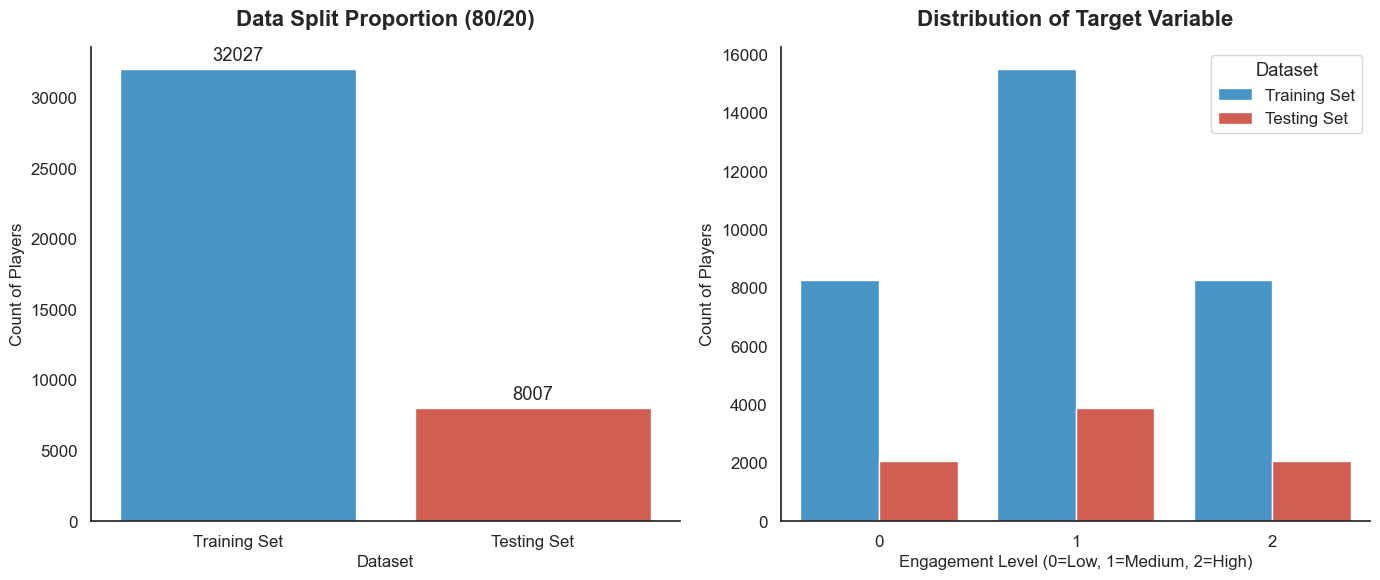

In [31]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Separate Features (X) and Target (y)
# (Using the 'df' that was already cleaned, scaled, and encoded in the previous steps)
X = df.drop('EngagementLevel', axis=1)
y = df['EngagementLevel']

# Split the Data into Training and Testing Sets
# Added stratify=y to ensure the 0, 1, 2 classes are perfectly balanced in both splits!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify the Shapes
print("Total dataset size:", df.shape)
print("Training set size (X_train):", X_train.shape)
print("Testing set size (X_test):", X_test.shape)
print("\n")

# Visualize the Split
train_plot_df = pd.DataFrame({'Engagement Level': y_train, 'Dataset': 'Training Set'})
test_plot_df = pd.DataFrame({'Engagement Level': y_test, 'Dataset': 'Testing Set'})
plot_df = pd.concat([train_plot_df, test_plot_df])

# Set a Nice Style and Colors
sns.set_style("white")
colors = ['#3498db', '#e74c3c']

# Create the Figure with 1 Row and 2 Columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart A: Data Split Proportion
ax1 = sns.countplot(x='Dataset', data=plot_df, hue='Dataset', palette=colors, ax=axes[0], legend=False)
ax1.set_title('Data Split Proportion (80/20)', fontsize=16, weight='bold', pad=15)
ax1.set_xlabel('Dataset', fontsize=12)
ax1.set_ylabel('Count of Players', fontsize=12)

# Add data labels to the first chart
for container in ax1.containers:
    ax1.bar_label(container, padding=3)

# Chart B: Target Variable Distribution
ax2 = sns.countplot(x='Engagement Level', hue='Dataset', data=plot_df, palette=colors, ax=axes[1])
ax2.set_title('Distribution of Target Variable', fontsize=16, weight='bold', pad=15)
ax2.set_xlabel('Engagement Level (0=Low, 1=Medium, 2=High)', fontsize=12)
ax2.set_ylabel('Count of Players', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

### Model 1: Logistic Regression (Baseline Model)

 MODEL 1: COMPREHENSIVE LOGISTIC REGRESSION (GRID SEARCH OPTIMIZED) 
Running Grid Search to find the best Logistic Regression parameters...

--- OPTIMAL PARAMETERS FOUND ---
Best C (Regularization): 0.1
Best Solver:             lbfgs
--------------------------------

 --- TRAIN VS TEST PERFORMANCE ---
             Accuracy Precision  Recall F1-Score   AUC  
Training Set  90.44%    90.54%   90.44%  90.44%   95.79%
Testing Set   90.40%    90.51%   90.40%  90.41%   95.71%

 --- CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

         Low       0.89      0.90      0.90      2065
      Medium       0.89      0.92      0.90      3875
        High       0.95      0.88      0.91      2067

    accuracy                           0.90      8007
   macro avg       0.91      0.90      0.90      8007
weighted avg       0.91      0.90      0.90      8007



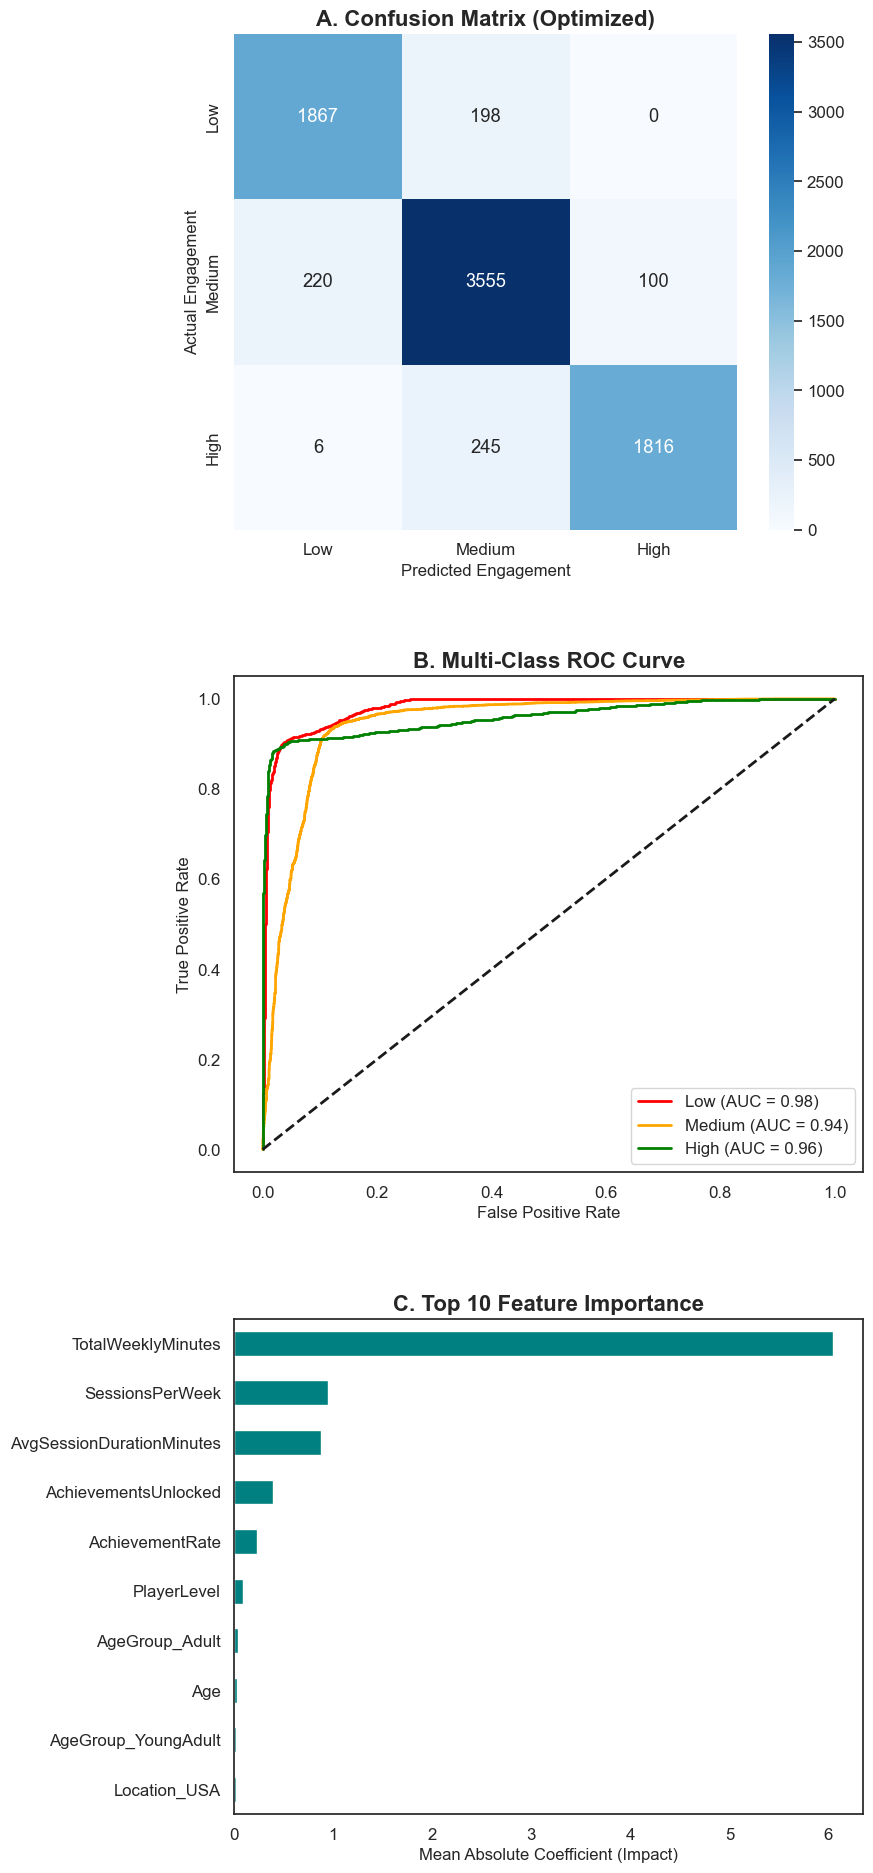

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit the scaler on the training data ONLY, and transform it
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# 3. Transform the testing data using the SAME scaler
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# ============================================================================
# 1: HYPERPARAMETER TUNING (Find the absolute best settings)
# ============================================================================
print("="*75)
print(" MODEL 1: COMPREHENSIVE LOGISTIC REGRESSION (GRID SEARCH OPTIMIZED) ")
print("="*75)

print("Running Grid Search to find the best Logistic Regression parameters...")

# Define the grid of settings to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],       # Inverse of regularization strength
    'solver': ['lbfgs', 'liblinear'],   # Different mathematical solvers
    'max_iter': [1000]                  # Give it plenty of time to converge
}

# Initialize a base Logistic Regression model
base_logreg = LogisticRegression(random_state=42)

# Run the automated search
grid_search = GridSearchCV(estimator=base_logreg, param_grid=param_grid, 
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the absolute best model from the search
logreg = grid_search.best_estimator_

class_names = ['Low', 'Medium', 'High']

print("\n--- OPTIMAL PARAMETERS FOUND ---")
print(f"Best C (Regularization): {grid_search.best_params_['C']}")
print(f"Best Solver:             {grid_search.best_params_['solver']}")
print("-" * 32)

# ============================================================================
# 2: GET PREDICTIONS & PROBABILITIES
# ============================================================================
# Get predictions for BOTH Train and Test (needed for the comparison table)
y_train_pred = logreg.predict(X_train)
y_train_proba = logreg.predict_proba(X_train)

y_test_pred = logreg.predict(X_test)
y_test_proba = logreg.predict_proba(X_test)

# 3: PRINT METRICS & PERFORMANCE TABLE
# Helper function to calculate all metrics
def get_metrics(y_true, y_pred, y_proba):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    ]

train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)

# Print Train vs Test Comparison Table
metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    index=['Training Set', 'Testing Set']
)

print("\n --- TRAIN VS TEST PERFORMANCE ---")
formatted_df = metrics_df.copy()
for col in formatted_df.columns:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.2%}")
print(formatted_df.to_string(justify='center'))

# Print Classification Report
print("\n --- CLASSIFICATION REPORT (TEST SET) ---")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ============================================================================
# 4: VISUALIZATIONS (Vertical Layout: 3 Rows x 1 Column)
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

# --- Plot A: Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, 
            yticklabels=class_names)
axes[0].set_title('A. Confusion Matrix (Optimized)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Engagement', fontsize=12)
axes[0].set_ylabel('Actual Engagement', fontsize=12)

# --- Plot B: Multi-Class ROC Curve ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
colors = ['red', 'orange', 'green']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = class_names[i]
    axes[1].plot(fpr, tpr, color=color, lw=2, 
                 label=f'{class_name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title('B. Multi-Class ROC Curve', fontsize=16, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc="lower right")

# --- Plot C: Feature Importance (Coefficients) ---
importance = np.mean(np.abs(logreg.coef_), axis=0)
feat_imp = pd.Series(importance, index=X_train.columns).sort_values(ascending=True)

feat_imp.tail(10).plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('C. Top 10 Feature Importance', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Mean Absolute Coefficient (Impact)', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

### Model 2: Random Forest


 MODEL 2: COMPREHENSIVE RANDOM FOREST (GRID SEARCH OPTIMIZED) 
Running Grid Search to find the best Random Forest parameters... (This may take a minute!)

--- OPTIMAL PARAMETERS FOUND ---
Best Trees (n_est):     100
Best Max Depth:         20
Best Min Samples Split: 5
Best Min Samples Leaf:  2
--------------------------------

 --- TRAIN VS TEST PERFORMANCE ---
             Accuracy Precision  Recall F1-Score   AUC  
Training Set  97.73%    97.74%   97.73%  97.72%   99.93%
Testing Set   95.10%    95.16%   95.10%  95.10%   98.52%

 --- CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

         Low       0.95      0.96      0.96      2065
      Medium       0.94      0.96      0.95      3875
        High       0.97      0.92      0.94      2067

    accuracy                           0.95      8007
   macro avg       0.96      0.95      0.95      8007
weighted avg       0.95      0.95      0.95      8007



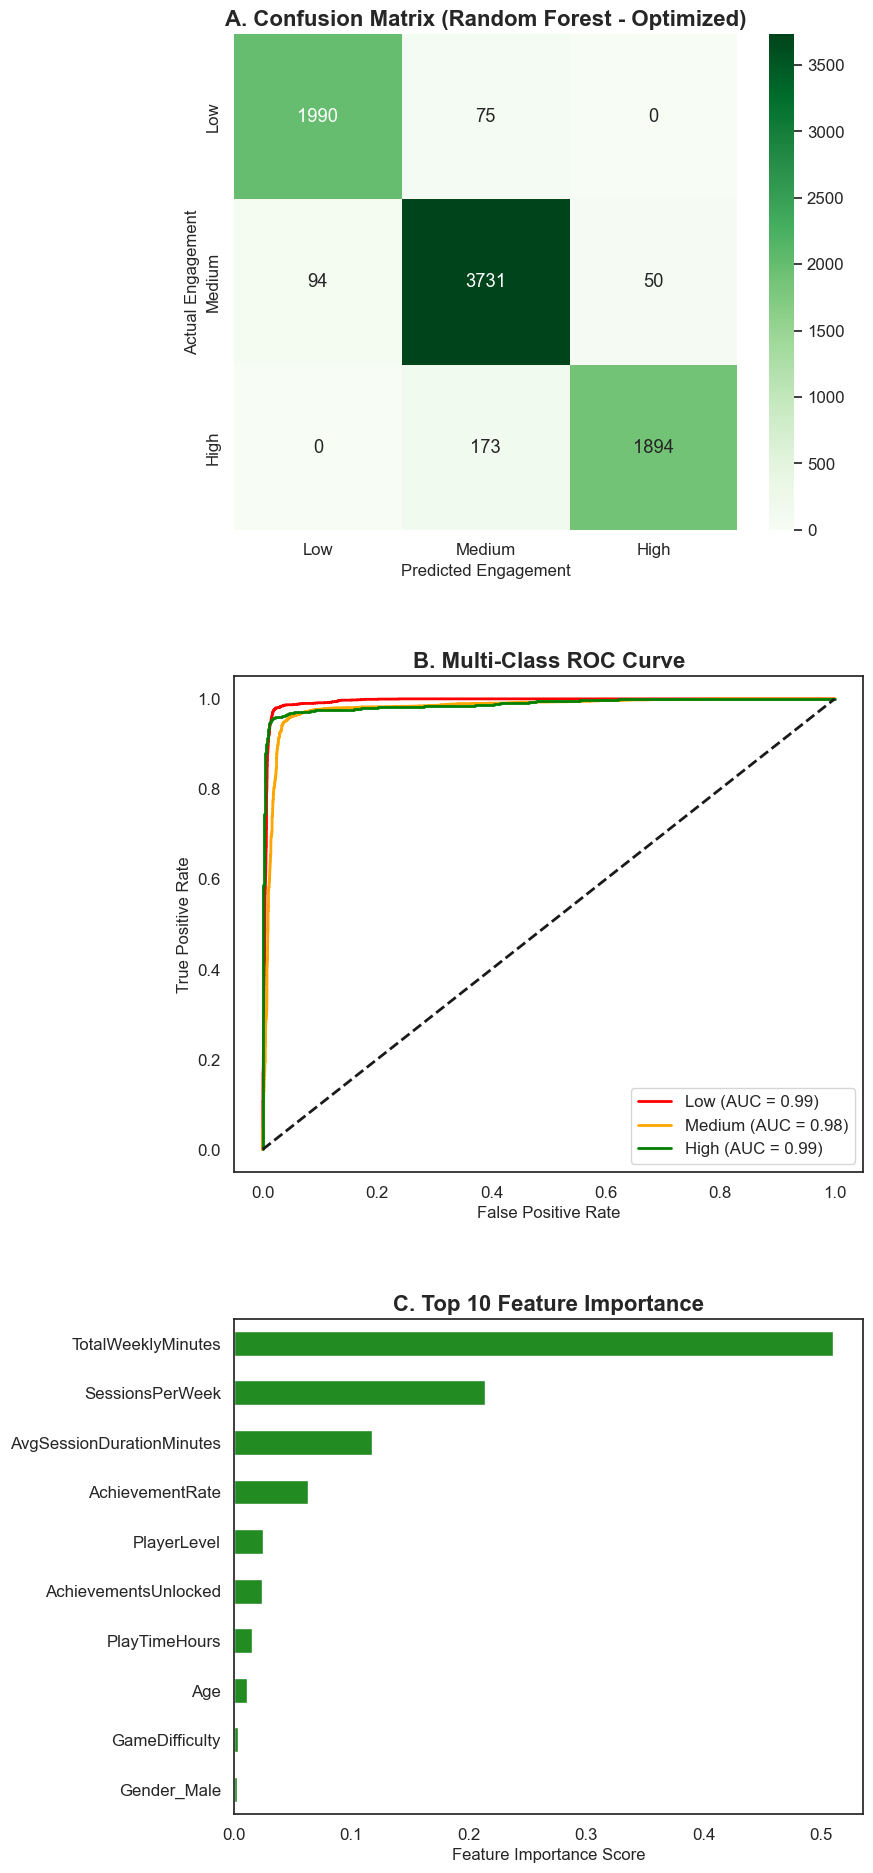

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("="*75)
print(" MODEL 2: COMPREHENSIVE RANDOM FOREST (GRID SEARCH OPTIMIZED) ")
print("="*75)

class_names = ['Low', 'Medium', 'High']

# ============================================================================
# 1. HYPERPARAMETER TUNING (Find the absolute best settings)
# ============================================================================
print("Running Grid Search to find the best Random Forest parameters... (This may take a minute!)")

# Define the grid of settings to test
param_grid = {
    'n_estimators': [100, 200],        # Number of trees in the forest
    'max_depth': [10, 15, 20],         # Maximum depth of the trees
    'min_samples_split': [5, 10],      # Minimum samples required to split a node
    'min_samples_leaf': [2, 5]         # Minimum samples required to be at a leaf node
}

# Initialize a base Random Forest model
base_rf = RandomForestClassifier(random_state=42)

# Run the automated search
grid_search = GridSearchCV(estimator=base_rf, param_grid=param_grid, 
                           cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the absolute best model from the search
rf_model = grid_search.best_estimator_

print("\n--- OPTIMAL PARAMETERS FOUND ---")
print(f"Best Trees (n_est):     {grid_search.best_params_['n_estimators']}")
print(f"Best Max Depth:         {grid_search.best_params_['max_depth']}")
print(f"Best Min Samples Split: {grid_search.best_params_['min_samples_split']}")
print(f"Best Min Samples Leaf:  {grid_search.best_params_['min_samples_leaf']}")
print("-" * 32)

# ============================================================================
# 2. Get Predictions and Probabilities (For both Train and Test)
# ============================================================================
y_train_pred = rf_model.predict(X_train)
y_train_proba = rf_model.predict_proba(X_train)

y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)

# ============================================================================
# 3. Helper function to calculate all metrics
# ============================================================================
def get_metrics(y_true, y_pred, y_proba):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    ]

train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)

# ============================================================================
# 4. Print Train vs Test Comparison Table
# ============================================================================
metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    index=['Training Set', 'Testing Set']
)

print("\n --- TRAIN VS TEST PERFORMANCE ---")
formatted_df = metrics_df.copy()
for col in formatted_df.columns:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.2%}")
print(formatted_df.to_string(justify='center'))

print("\n --- CLASSIFICATION REPORT (TEST SET) ---")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ============================================================================
# 5. VISUALIZATIONS (Vertical Layout: 3 Rows x 1 Column)
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

# --- Plot A: Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=class_names, 
            yticklabels=class_names)
axes[0].set_title('A. Confusion Matrix (Random Forest - Optimized)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Engagement', fontsize=12)
axes[0].set_ylabel('Actual Engagement', fontsize=12)

# --- Plot B: Multi-Class ROC Curve ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
colors = ['red', 'orange', 'green']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = class_names[i]
    axes[1].plot(fpr, tpr, color=color, lw=2, 
                 label=f'{class_name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title('B. Multi-Class ROC Curve', fontsize=16, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc="lower right")

# --- Plot C: Feature Importance (Random Forest Specific) ---
importance = rf_model.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns).sort_values(ascending=True)

feat_imp.tail(10).plot(kind='barh', ax=axes[2], color='forestgreen')
axes[2].set_title('C. Top 10 Feature Importance', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Feature Importance Score', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

### Model 3: K-Nearest Neighbors (KNN)

  MODEL 3: COMPREHENSIVE KNN (GRID SEARCH OPTIMIZED) 
Running Grid Search to find the best KNN parameters... (This may take a moment)

--- OPTIMAL PARAMETERS FOUND ---
Best K (n_neighbors): 43
Best Weights:         uniform
Best Metric:          manhattan
--------------------------------

 --- TRAIN VS TEST PERFORMANCE ---
             Accuracy Precision  Recall F1-Score   AUC  
Training Set  85.48%    87.04%   85.48%  85.35%   95.00%
Testing Set   84.61%    86.41%   84.61%  84.44%   94.04%

 --- CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

         Low       0.93      0.71      0.80      2065
      Medium       0.78      0.96      0.86      3875
        High       0.96      0.78      0.86      2067

    accuracy                           0.85      8007
   macro avg       0.89      0.81      0.84      8007
weighted avg       0.86      0.85      0.84      8007


Calculating Permutation Importance for Optimized KNN...


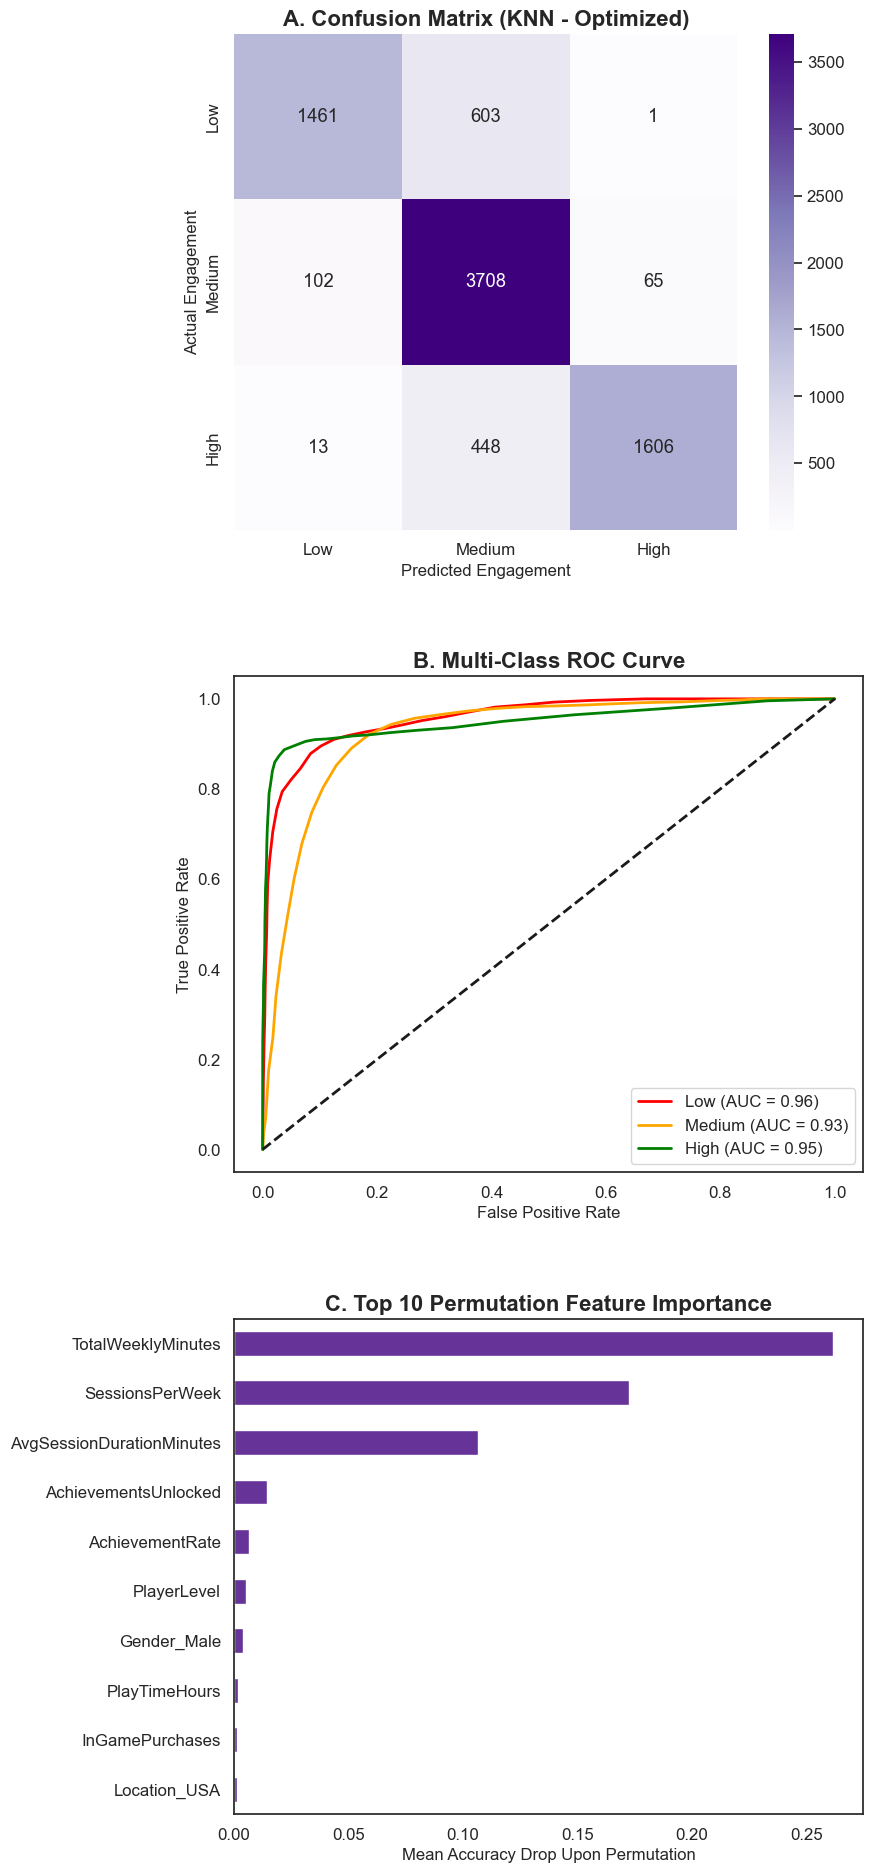

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("="*75)
print("  MODEL 3: COMPREHENSIVE KNN (GRID SEARCH OPTIMIZED) ")
print("="*75)

class_names = ['Low', 'Medium', 'High']

# ============================================================================
# 1. HYPERPARAMETER TUNING (Find the absolute best settings)
# ============================================================================
print("Running Grid Search to find the best KNN parameters... (This may take a moment)")

# Define the "grid" of settings you want the computer to test
param_grid = {
    'n_neighbors': np.arange(5, 50),  # Tests odd numbers from 5 to 49
    'weights': ['uniform'],  # Tests equal voting vs closer-point voting
    'metric': ['euclidean', 'manhattan'] # Tests different geometric distance formulas
}

# Initialize a base KNN model
base_knn = KNeighborsClassifier()

# Run the automated search
grid_search = GridSearchCV(estimator=base_knn, param_grid=param_grid, 
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the absolute best model from the search
knn_model = grid_search.best_estimator_

print("\n--- OPTIMAL PARAMETERS FOUND ---")
print(f"Best K (n_neighbors): {grid_search.best_params_['n_neighbors']}")
print(f"Best Weights:         {grid_search.best_params_['weights']}")
print(f"Best Metric:          {grid_search.best_params_['metric']}")
print("-" * 32)

# ============================================================================
# 2. Get Predictions and Probabilities (For both Train and Test)
# ============================================================================
y_train_pred = knn_model.predict(X_train)
y_train_proba = knn_model.predict_proba(X_train)

y_test_pred = knn_model.predict(X_test)
y_test_proba = knn_model.predict_proba(X_test)

# ============================================================================
# 3. Helper function to calculate all metrics
# ============================================================================
def get_metrics(y_true, y_pred, y_proba):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    ]

train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)

# ============================================================================
# 4. Print Train vs Test Comparison Table
# ============================================================================
metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    index=['Training Set', 'Testing Set']
)

print("\n --- TRAIN VS TEST PERFORMANCE ---")
formatted_df = metrics_df.copy()
for col in formatted_df.columns:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.2%}")
print(formatted_df.to_string(justify='center'))

print("\n --- CLASSIFICATION REPORT (TEST SET) ---")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ============================================================================
# 5. VISUALIZATIONS (Vertical Layout: 3 Rows x 1 Column)
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

# --- Plot A: Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=class_names, 
            yticklabels=class_names)
axes[0].set_title('A. Confusion Matrix (KNN - Optimized)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Engagement', fontsize=12)
axes[0].set_ylabel('Actual Engagement', fontsize=12)

# --- Plot B: Multi-Class ROC Curve ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
colors = ['red', 'orange', 'green']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = class_names[i]
    axes[1].plot(fpr, tpr, color=color, lw=2, 
                 label=f'{class_name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title('B. Multi-Class ROC Curve', fontsize=16, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc="lower right")

# --- Plot C: Permutation Feature Importance ---
print("\nCalculating Permutation Importance for Optimized KNN...")
perm_result = permutation_importance(knn_model, X_test, y_test, n_repeats=3, random_state=42, n_jobs=-1)
sorted_idx = perm_result.importances_mean.argsort()

feat_imp = pd.Series(perm_result.importances_mean[sorted_idx], index=X_test.columns[sorted_idx])
feat_imp.tail(10).plot(kind='barh', ax=axes[2], color='rebeccapurple')
axes[2].set_title('C. Top 10 Permutation Feature Importance', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Mean Accuracy Drop Upon Permutation', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

### Model 4: XGBOOST

 MODEL 4: COMPREHENSIVE XGBOOST (GRID SEARCH OPTIMIZED) 
Running Grid Search to find the best XGBoost parameters... (This may take a minute!)

--- OPTIMAL PARAMETERS FOUND ---
Best Max Depth:     7
Best Learning Rate: 0.1
Best Trees (n_est): 100
--------------------------------

 --- TRAIN VS TEST PERFORMANCE ---
             Accuracy Precision  Recall F1-Score   AUC  
Training Set  97.51%    97.52%   97.51%  97.50%   99.54%
Testing Set   96.94%    96.96%   96.94%  96.94%   98.92%

 --- CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

         Low       0.97      0.98      0.97      2065
      Medium       0.96      0.97      0.97      3875
        High       0.98      0.95      0.97      2067

    accuracy                           0.97      8007
   macro avg       0.97      0.97      0.97      8007
weighted avg       0.97      0.97      0.97      8007



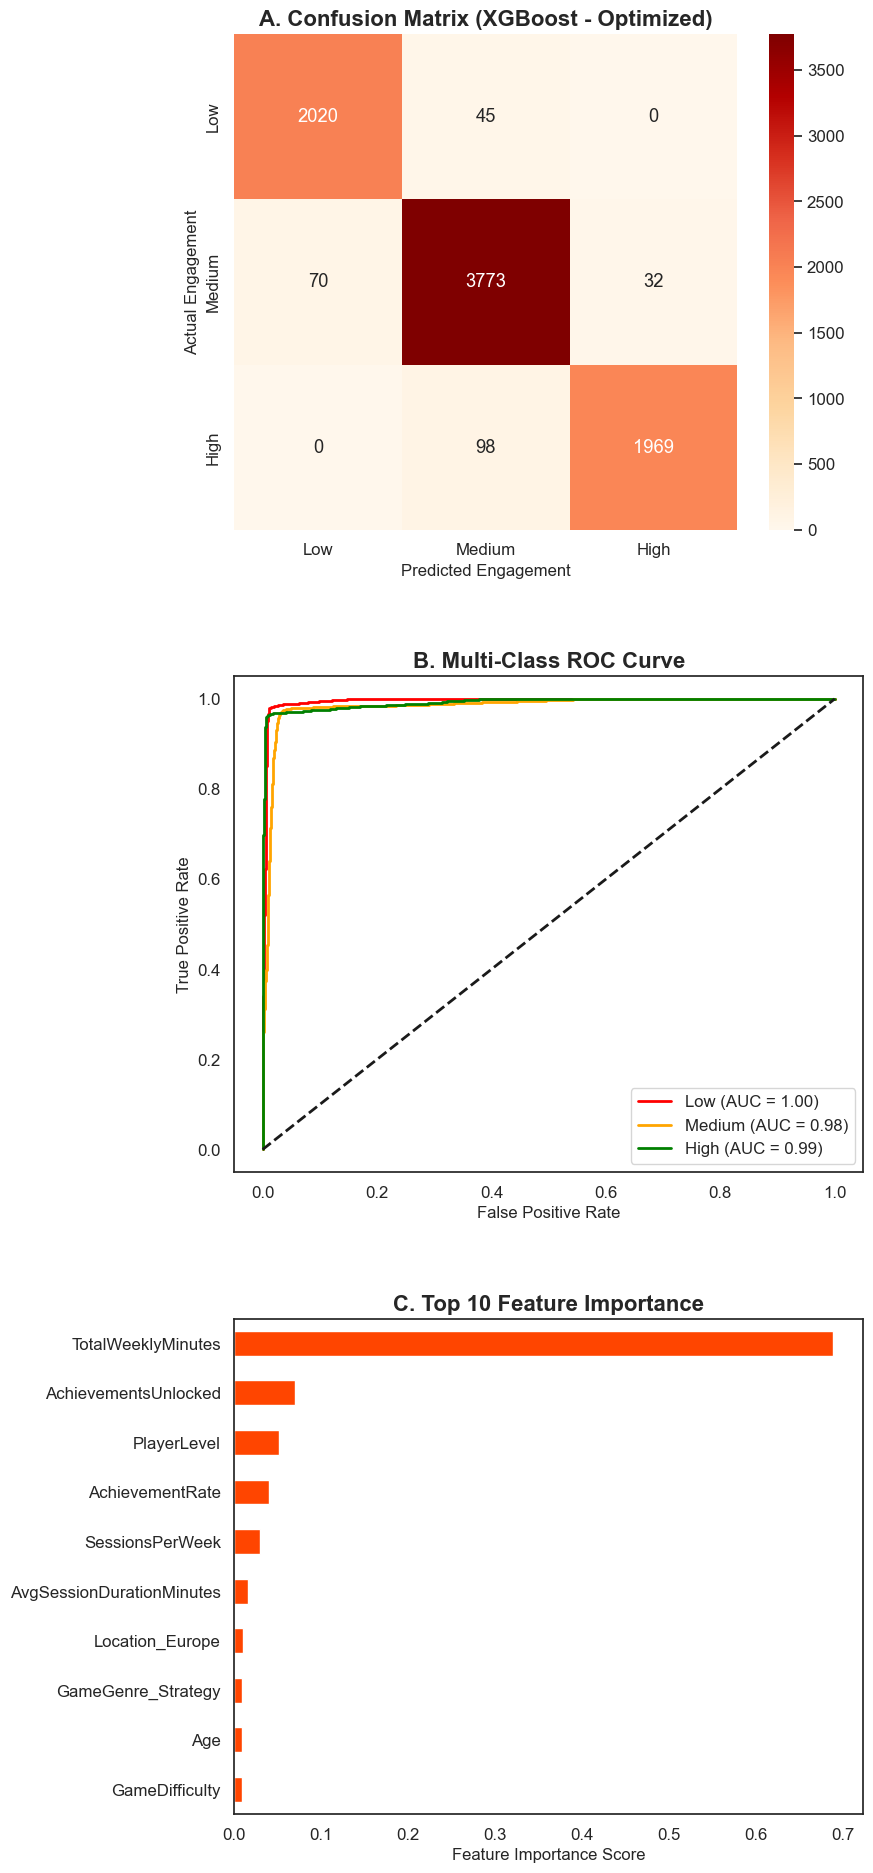

In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("="*75)
print(" MODEL 4: COMPREHENSIVE XGBOOST (GRID SEARCH OPTIMIZED) ")
print("="*75)

class_names = ['Low', 'Medium', 'High']

# ============================================================================
# 1. HYPERPARAMETER TUNING (Find the absolute best settings)
# ============================================================================
print("Running Grid Search to find the best XGBoost parameters... (This may take a minute!)")

# Define the grid of settings to test
param_grid = {
    'max_depth': [3, 5, 7],             # How deep each tree can grow
    'learning_rate': [0.01, 0.1, 0.2],  # How aggressively the model corrects its mistakes
    'n_estimators': [50, 100, 200]      # Total number of trees to build
}

# Initialize a base XGBoost model
base_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

# Run the automated search (cv=3 means 3-fold cross validation to speed it up slightly)
grid_search = GridSearchCV(estimator=base_xgb, param_grid=param_grid, 
                           cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the absolute best model from the search
xgb_model = grid_search.best_estimator_

print("\n--- OPTIMAL PARAMETERS FOUND ---")
print(f"Best Max Depth:     {grid_search.best_params_['max_depth']}")
print(f"Best Learning Rate: {grid_search.best_params_['learning_rate']}")
print(f"Best Trees (n_est): {grid_search.best_params_['n_estimators']}")
print("-" * 32)

# ============================================================================
# 2. Get Predictions and Probabilities (For both Train and Test)
# ============================================================================
y_train_pred = xgb_model.predict(X_train)
y_train_proba = xgb_model.predict_proba(X_train)

y_test_pred = xgb_model.predict(X_test)
y_test_proba = xgb_model.predict_proba(X_test)

# ============================================================================
# 3. Helper function to calculate all metrics
# ============================================================================
def get_metrics(y_true, y_pred, y_proba):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    ]

train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)

# ============================================================================
# 4. Print Train vs Test Comparison Table
# ============================================================================
metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    index=['Training Set', 'Testing Set']
)

print("\n --- TRAIN VS TEST PERFORMANCE ---")
formatted_df = metrics_df.copy()
for col in formatted_df.columns:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.2%}")
print(formatted_df.to_string(justify='center'))

print("\n --- CLASSIFICATION REPORT (TEST SET) ---")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

# ============================================================================
# 5. VISUALIZATIONS (Vertical Layout: 3 Rows x 1 Column)
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

# --- Plot A: Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', ax=axes[0],
            xticklabels=class_names, 
            yticklabels=class_names)
axes[0].set_title('A. Confusion Matrix (XGBoost - Optimized)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Engagement', fontsize=12)
axes[0].set_ylabel('Actual Engagement', fontsize=12)

# --- Plot B: Multi-Class ROC Curve ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]
colors = ['red', 'orange', 'green']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    class_name = class_names[i]
    axes[1].plot(fpr, tpr, color=color, lw=2, 
                 label=f'{class_name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_title('B. Multi-Class ROC Curve', fontsize=16, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc="lower right")

# --- Plot C: Feature Importance (XGBoost Specific) ---
importance = xgb_model.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns).sort_values(ascending=True)

feat_imp.tail(10).plot(kind='barh', ax=axes[2], color='orangered')
axes[2].set_title('C. Top 10 Feature Importance', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Feature Importance Score', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

 FINAL MODEL COMPARISON (TEST SET PERFORMANCE) 

--- PERFORMANCE SUMMARY TABLE ---
       Model        Accuracy Precision Recall F1-Score  AUC  
Logistic Regression  90.40%    90.51%  90.40%  90.41%  95.71%
      Random Forest  95.10%    95.16%  95.10%  95.10%  98.52%
                KNN  84.61%    86.41%  84.61%  84.44%  94.04%
            XGBoost  96.94%    96.96%  96.94%  96.94%  98.92%


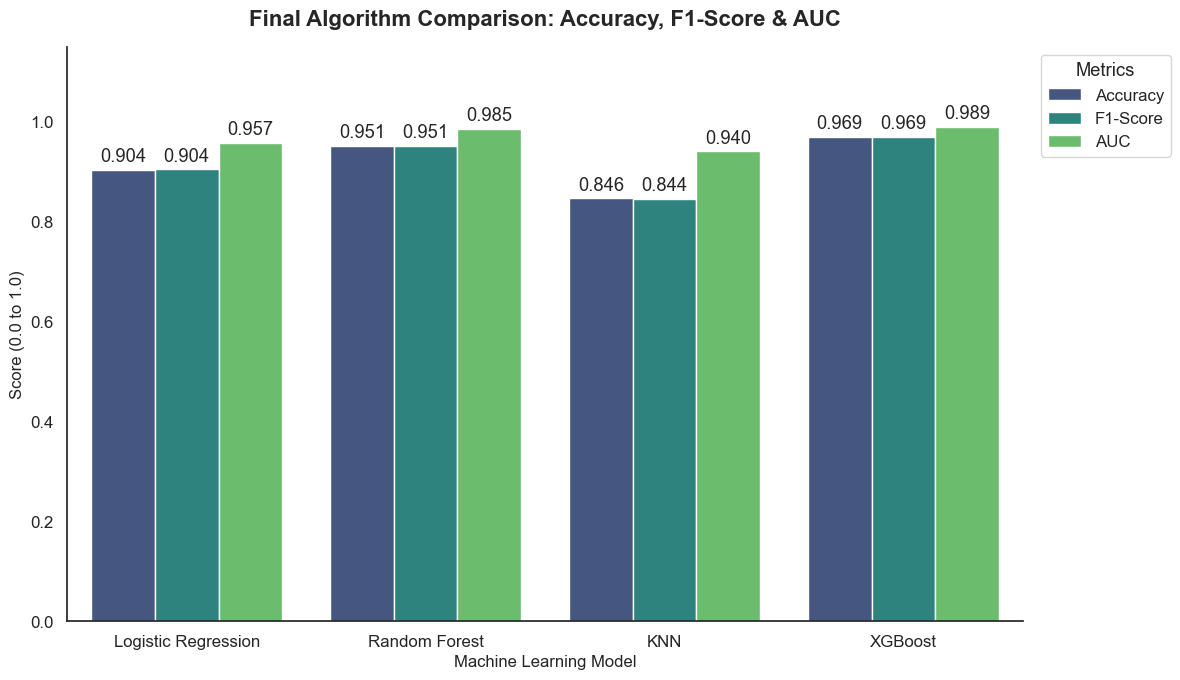

In [36]:
print("="*75)
print(" FINAL MODEL COMPARISON (TEST SET PERFORMANCE) ")
print("="*75)

# 1. Gather all optimized models into a dictionary
models = {
    'Logistic Regression': logreg,      
    'Random Forest': rf_model,          
    'KNN': knn_model,                   
    'XGBoost': xgb_model                
}

# 2. Loop through each model to calculate its metrics on the Test Set
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc_val = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    
    results.append([name, acc, prec, rec, f1, auc_val])

# 3. Create a clean Pandas DataFrame for the table
comparison_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'])

# Display the formatted table
display_df = comparison_df.copy()
for col in display_df.columns[1:]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
print("\n--- PERFORMANCE SUMMARY TABLE ---")
print(display_df.to_string(index=False, justify='center'))

# ============================================================================
# 4. VISUALIZE THE COMPARISON
# ============================================================================
# Filter the dataframe to only plot the most important metrics
melted_df = pd.melt(comparison_df, id_vars="Model", var_name="Metric", value_name="Score")
plot_data = melted_df[melted_df['Metric'].isin(['Accuracy', 'F1-Score', 'AUC'])]

plt.figure(figsize=(12, 7))

# Create a grouped bar chart
sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Final Algorithm Comparison: Accuracy, F1-Score & AUC', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.15) # Gives extra room at the top for the data labels

# Move the legend outside
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Metrics')

# Add exact numbers on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

sns.despine()
plt.tight_layout()
plt.show()